# ***Sales Performance and Shipping Efficiency: An In-Depth EDA 📊***

# *1. Data Loading & Initial Inspection*

*Import libraries for EDA :*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

*Configure visualization settings :*

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

 *Load dataset :*

In [ ]:
url = 'https://raw.githubusercontent.com/adam30-111/US-Retail-Sales-Analysis/main/data/Sales_raw_data.csv'
df = pd.read_csv(url)

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.798
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.368
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.188
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.376
9799,9800,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384


The Data consists of online products sales and shipping to various states in The USA ✈📦

In [ ]:
df.shape

(9800, 18)

*Display column names to understand dataset structure :*

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

*Show dataset info (data types, non-null values, memory usage) :*

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float



---



# *2. Data Cleaning*

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
df.dropna(subset=['Postal Code'], inplace=True)

**Handling Missing Values :**

The `Postal Code` column has **11 missing entries** out of 9,800 — only **0.11%** of the dataset. Since this is a tiny fraction and these records have no reliable way to be imputed (each postal code is unique to a specific city), we drop these rows entirely.

This is the safest approach because postal codes cannot be guessed or filled with averages. The dataset size drops from 9,800 → 9,789 rows, which has negligible impact on downstream analysis.

In [ ]:
df.duplicated().sum()

np.int64(0)

There are no duplicated columns.

In [ ]:
df.shape

(9789, 18)

There are 9789 rows.\
There are 18 columns.



---



# *3. Feature Engineering*

*Data Types of columns :*

In [ ]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)
df['Postal Code'] = df['Postal Code'].astype(int)

In [ ]:
print("Date range:", df['Order Date'].min(), "→", df['Order Date'].max())
df[['Order Date','Ship Date']].head()

Date range: 2015-01-03 00:00:00 → 2018-12-30 00:00:00


,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


Change the data type of Order Date and Ship Date from (object) to (datetime) to help with EDA.\
Change the data type of Postal Code from (float64) to (int64) because it is not a float; it is an integer.

*Extract year and month from Order Date and Ship Date for time-based analysis :*

In [ ]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Ship Year'] = df['Ship Date'].dt.year
df['Ship Month'] = df['Ship Date'].dt.month

*Compute shipping duration (in days) :*

In [ ]:
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [ ]:
df['Shipping Days'].describe()

,Shipping Days
count,9789.000000
mean,3.961181
std,1.750452
min,0.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,7.000000


In [ ]:
df.shape

(9789, 23)

There are 9789 rows.\
There are 23 columns.



---



# *4. Correlation Analysis*

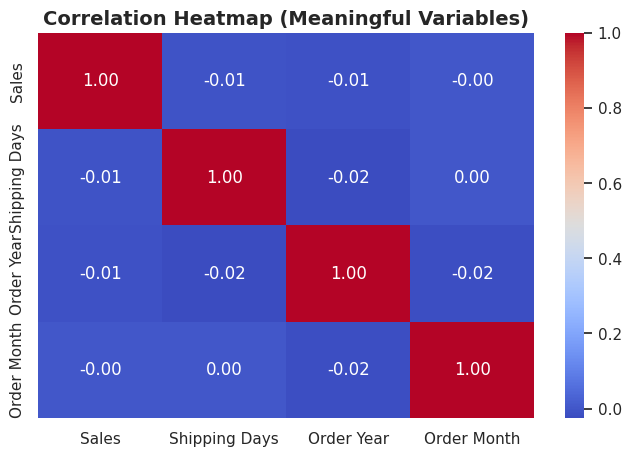

In [ ]:
numeric_cols = ['Sales', 'Shipping Days', 'Order Year', 'Order Month']
plt.figure(figsize=(8,5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Meaningful Variables)')
plt.show()

**Correlation Heatmap — Key Takeaways :**

All correlations between the numeric variables are **very weak**, with values close to zero across the board. Three important conclusions follow :

- **Sales are not driven by shipping speed** — pricing depends on the product, not on how fast it's delivered.
- **No strong linear time-trend at the daily level** — although seasonal patterns may still exist at the monthly aggregate level (explored in the Temporal Analysis section).
- **Each numeric feature carries independent information** — which is actually useful when building predictive models later, since the variables don't overlap or duplicate each other.

The absence of strong linear correlations means we should rely on **categorical drivers** (Category, Region, Segment, Ship Mode) and **non-linear models** to explain sales variation, rather than simple linear regression on the numeric features alone.



---



# *5. Shipping Analysis*

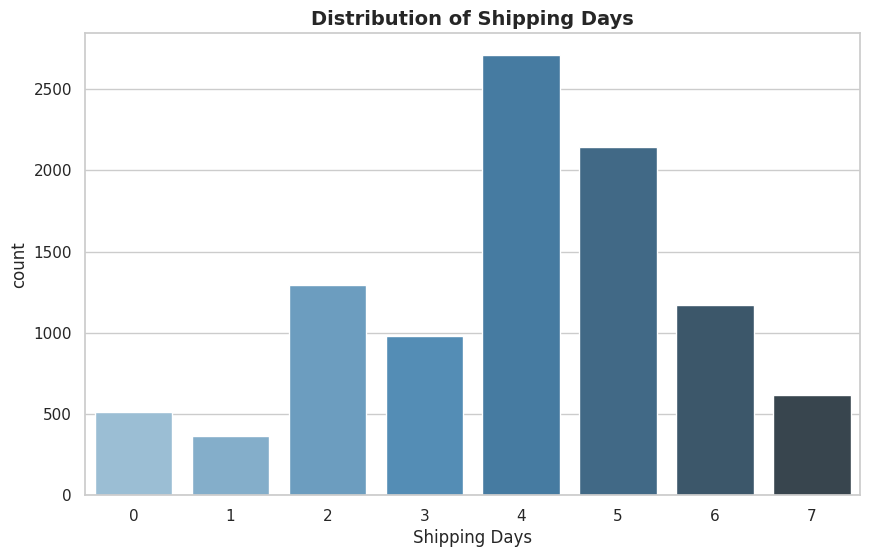

In [ ]:
sns.countplot(x='Shipping Days', data=df, palette='Blues_d')
plt.title('Distribution of Shipping Days'); plt.show()

**Shipping Days Distribution — Operational Excellence :**

The shipping pipeline is **highly efficient and tightly controlled :**

- Most orders are delivered within **3 to 5 days**, the typical e-commerce sweet spot.
- **Same-day delivery (0 days)** exists as an option but accounts for a small share of orders.
- The **maximum shipping time is 7 days** — there are no extreme delays anywhere in the dataset.

This narrow range (0 to 7 days) is a strong operational signal. It means the fulfillment network is **predictable, reliable, and within SLA**. There is no evidence of bottlenecks, lost shipments, or chronic delays. From a customer experience perspective, this consistency is one of the company's strongest assets.

In [ ]:
df['Ship Mode'].value_counts()

,count
Ship Mode,
Standard Class,5849
Second Class,1901
First Class,1501
Same Day,538


**Ship Mode Distribution :**

The breakdown reveals heavy concentration in lower-tier shipping :

- **Standard Class:**  59.7% — the dominant default choice.
- **Second Class:** 19.4%
- **First Class:** 15.3%
- **Same Day:** only 5.5% — significantly under-utilized.

**Business implication :** The combined share of premium shipping (First Class + Same Day) is only about 21%. This represents a clear **upsell opportunity**. By emphasizing the time-saving benefits of expedited delivery during checkout, especially for high-value Technology orders, the company can shift more customers toward higher-margin shipping tiers and boost overall revenue per order.

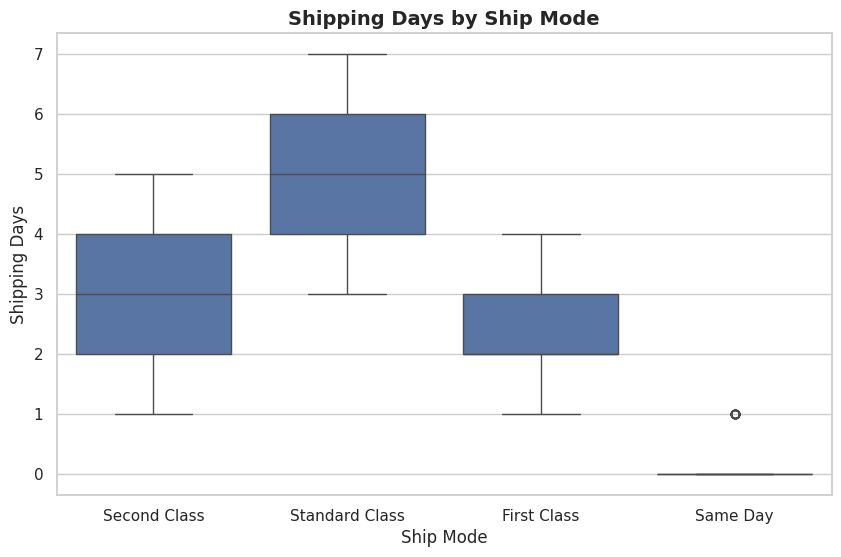

In [ ]:
sns.boxplot(x='Ship Mode', y='Shipping Days', data=df)

plt.title('Shipping Days by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Shipping Days')

plt.show()

**Shipping Days by Ship Mode — Each Tier Delivers Its SLA :**

The boxplot confirms that each shipping mode operates within its expected delivery window :

- **Standard Class:** typically arrives within **4 to 6 days**.
- **Second Class:** delivers in **2 to 4 days**.
- **First Class:** arrives within **48 to 72 hours** (1 to 3 days).
- **Same Day:** delivers on the same day the order is placed (0 days).

The clean separation between modes confirms that **service tiers are clearly differentiated** and customers receive exactly what they pay for. Minor variation within each tier may exist depending on the shipping distance, but no mode shows abnormal delays or SLA breaches.

In [ ]:
top_states = df.groupby('Ship Mode')['State'].value_counts().groupby(level=0).head(5)
print(top_states)

Ship Mode       State       
First Class     California       314
                New York         172
                Texas            140
                Pennsylvania     109
                Ohio              85
Same Day        California       117
                New York          62
                Ohio              52
                Texas             48
                Washington        39
Second Class    California       386
                New York         204
                Texas            188
                Washington       104
                Illinois         103
Standard Class  California      1129
                New York         659
                Texas            597
                Pennsylvania     367
                Washington       293
Name: count, dtype: int64


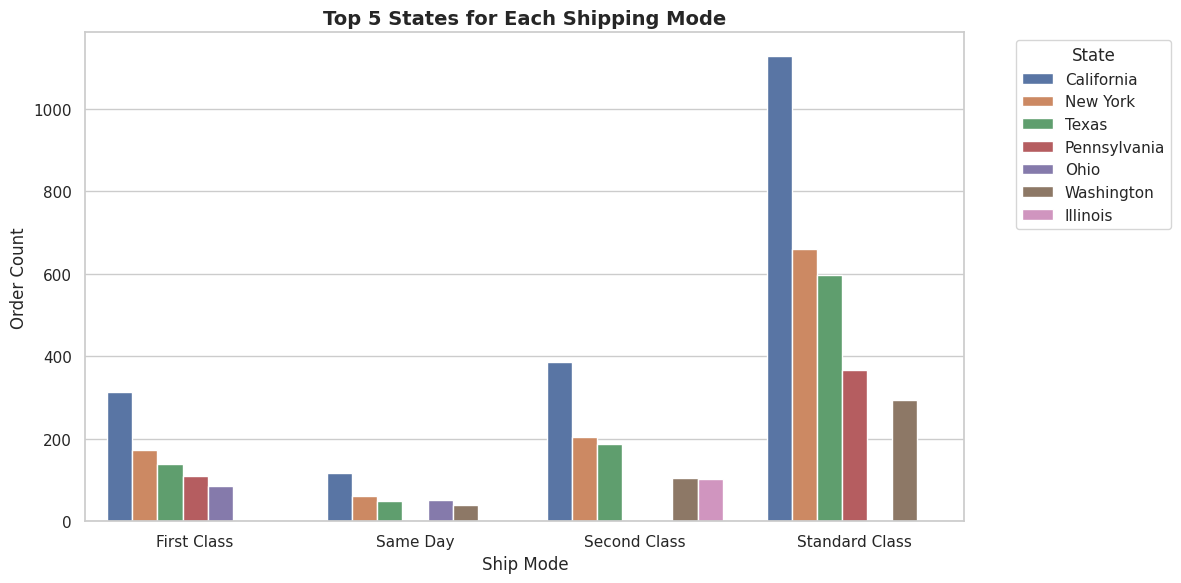

In [ ]:
counts = df.groupby(['Ship Mode', 'State']).size().reset_index(name='Order Count')
top_5_per_mode = counts.sort_values(['Ship Mode', 'Order Count'], ascending=[True, False]).groupby('Ship Mode').head(5)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_5_per_mode, x='Ship Mode', y='Order Count', hue='State')
plt.title('Top 5 States for Each Shipping Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Order Count')
plt.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Geographic concentration of shipping activity :**

- **California, New York, and Texas** appear as the top destinations across **every** shipping tier — Standard, Second, First, and Same Day.
- This "Big Three" dominance shows these states drive demand for **both standard and premium shipping**, not just high-volume basic orders.
- **California** clearly leads across all modes, reflecting the strategic value of distribution hubs near this market.

**Strategic implication :** Distribution centers and inventory should be optimized around these three states. Logistics partnerships and warehouse placement in CA, NY, and TX will directly impact overall fulfillment efficiency and customer satisfaction across all service tiers.

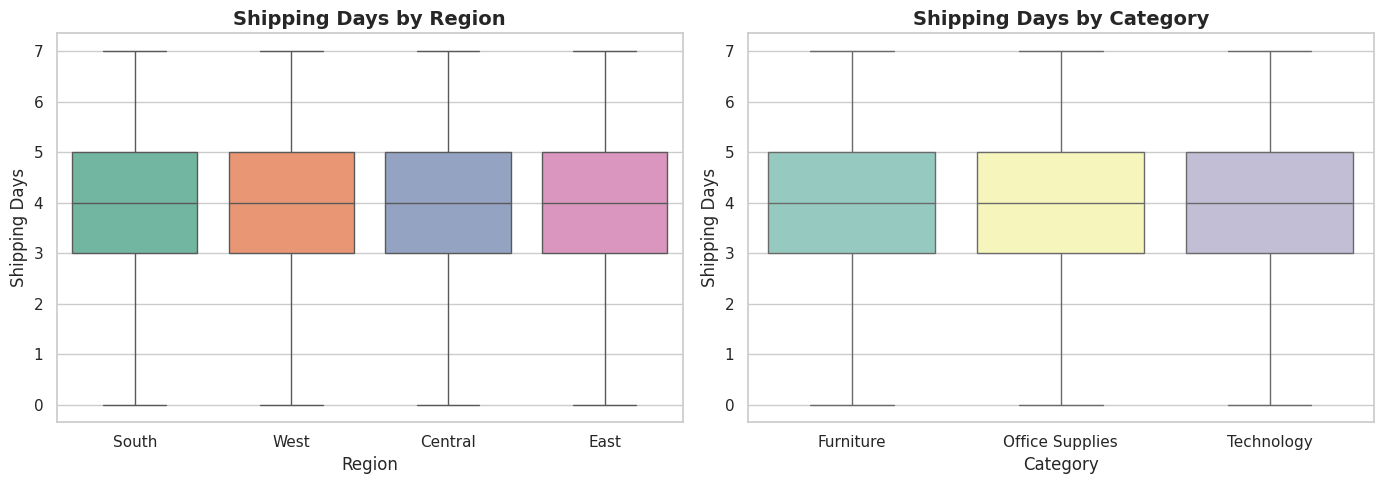

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(data=df, x='Region', y='Shipping Days', ax=axes[0], palette='Set2')
axes[0].set_title('Shipping Days by Region')

sns.boxplot(data=df, x='Category', y='Shipping Days', ax=axes[1], palette='Set3')
axes[1].set_title('Shipping Days by Category')
plt.tight_layout(); plt.show()

**Shipping consistency is remarkable across the board :**

- Average shipping time is **3.9–4.1 days** in every region (Central, East, South, West) — virtually identical.
- Product **category has no meaningful impact** on shipping duration either; Technology, Furniture, and Office Supplies all ship in the same time range.
- The boxplots show **near-identical medians and spreads** across all regions and categories.

**Business implication:** The company's logistics performance is **not bottlenecked by geography or product type** — a strong operational signal. This consistency means the fulfillment network is well-balanced and can scale into new regions without expecting performance drops. Any future shipping improvements will need to come from **service-tier optimization** (e.g., promoting faster modes) rather than fixing regional weak spots.



---



# *6. Customer & Segment Analysis*

In [ ]:
df['Customer Name'].value_counts().head(10)

,count
Customer Name,
William Brown,35
Paul Prost,34
Matt Abelman,34
John Lee,33
Chloris Kastensmidt,32
Jonathan Doherty,32
Seth Vernon,32
Arthur Prichep,31
Zuschuss Carroll,31


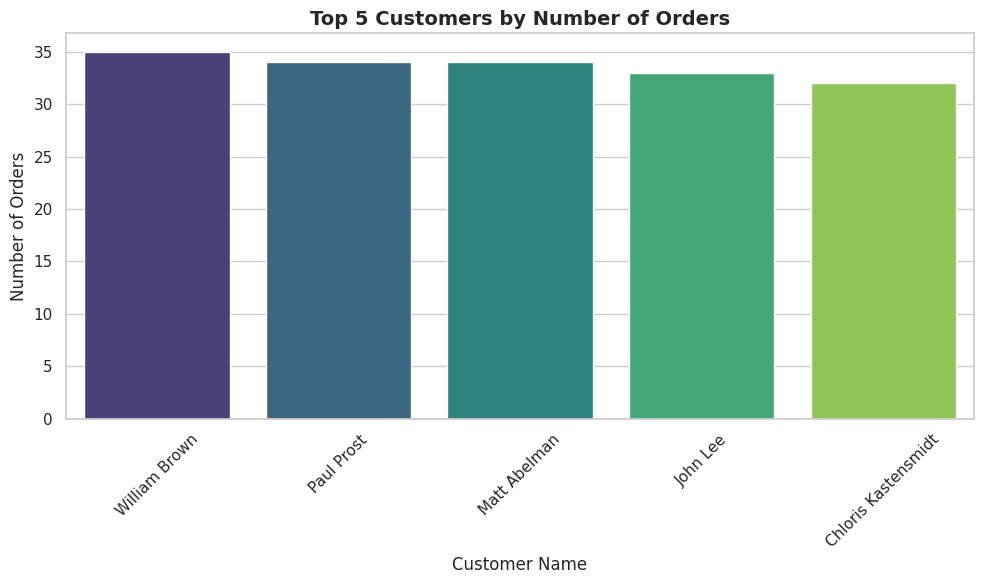

In [ ]:
top_5_customers = df['Customer Name'].value_counts().head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_5_customers.index, y=top_5_customers.values, palette='viridis')

plt.title('Top 5 Customers by Number of Orders')
plt.xlabel('Customer Name')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

CLV Stats:
 count      793.000000
mean      2840.614644
std       2618.950596
min          4.833000
25%       1080.751000
50%       2203.778000
75%       3644.978000
max      25043.050000
Name: Sales, dtype: float64


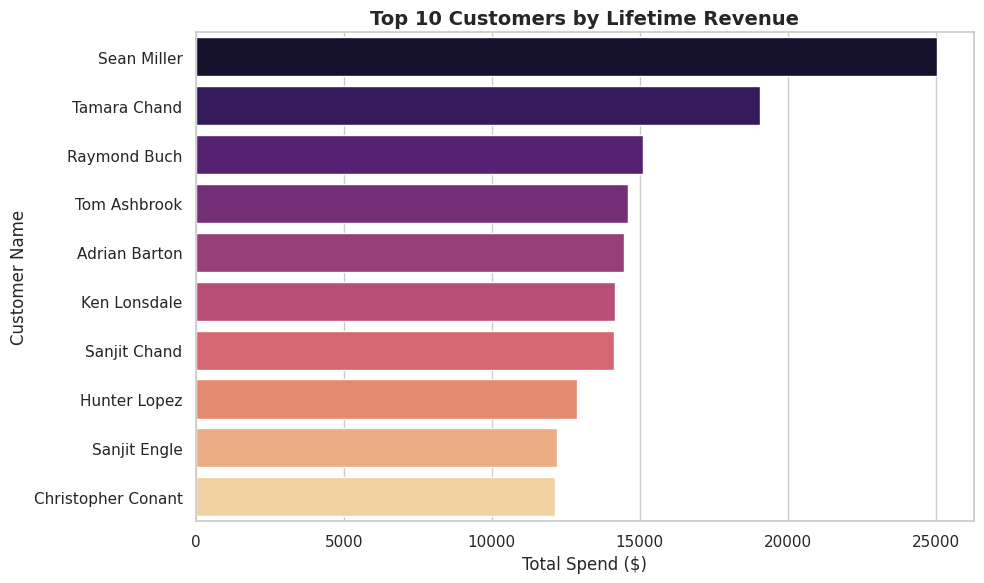

In [ ]:
clv = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False)
print("CLV Stats:\n", clv.describe())

top10_clv = clv.head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top10_clv.values, y=top10_clv.index, palette='magma')
plt.title('Top 10 Customers by Lifetime Revenue')
plt.xlabel('Total Spend ($)'); plt.tight_layout(); plt.show()

**Frequency ≠ Value — a critical customer insight :**

Comparing the two charts reveals **zero overlap** between the top 10 customers by order count and the top 10 by lifetime revenue. They are **two completely different groups :**

- **Frequent buyers** (e.g., William Brown — 35 orders) are **consistent small-basket shoppers**.
- **High-value buyers** (e.g., Sean Miller — $25K total) buy less often but spend big — over **11× the median customer spend**.

**Action :** These two segments need **different strategies** — loyalty programs for frequent buyers, and VIP/account-management programs for high-spenders. Treating them identically wastes both opportunities.

In [ ]:
df['Segment'].value_counts()

,count
Segment,
Consumer,5096
Corporate,2948
Home Office,1745


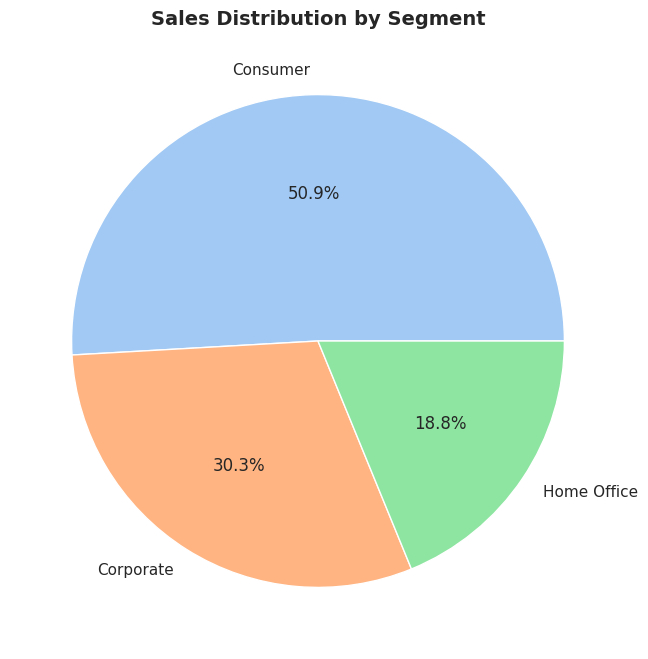

In [ ]:
plt.figure(figsize=(8, 8))
segment_sales = df.groupby('Segment')['Sales'].sum()
plt.pie(segment_sales, labels=segment_sales.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Sales Distribution by Segment')
plt.savefig('segment_sales.png', bbox_inches='tight')
plt.show()

Overall Average Order Value: $458.22

AOV by Segment:
 Segment
Consumer       452.35
Corporate      458.48
Home Office    474.45
Name: Sales, dtype: float64


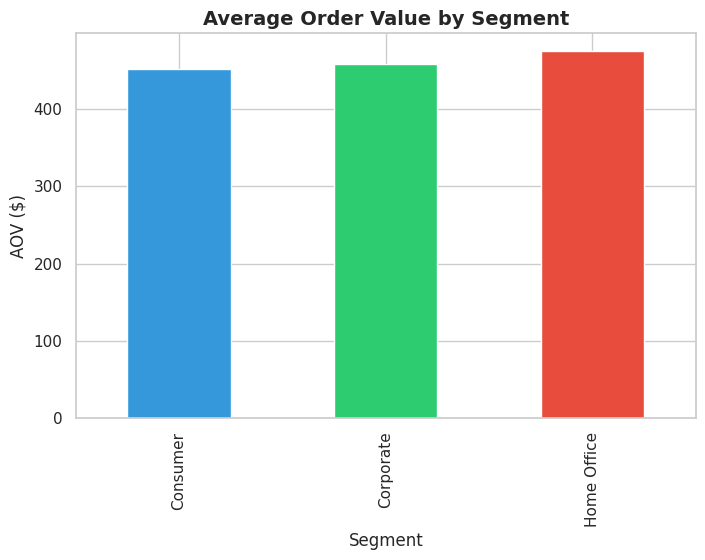

In [ ]:
aov = df.groupby('Order ID')['Sales'].sum().mean()
print(f"Overall Average Order Value: ${aov:.2f}")

aov_seg = df.groupby(['Order ID']).agg({'Sales':'sum','Segment':'first'}).groupby('Segment')['Sales'].mean()
print("\nAOV by Segment:\n", aov_seg.round(2))

aov_seg.plot(kind='bar', color=['#3498db','#2ecc71','#e74c3c'], figsize=(8,5))
plt.title('Average Order Value by Segment'); plt.ylabel('AOV ($)'); plt.show()

**Segment revenue gap ≠ basket size gap :**

The Consumer segment drives 51% of revenue, but the **AOV is nearly identical across all three segments ($452 - 474)**. This means the revenue differences come from **how many customers each segment has and how often they order**, not from spending more per order.

**Strategic implication:** Growing Corporate (30%) and Home Office (19%) is about **acquiring more customers** in these segments — not about increasing their basket size (already on par with Consumer). B2B account programs, bulk-purchase incentives, and dedicated reps are the right levers — not discounts to inflate order size.

Interesting bonus: **Home Office has the highest AOV ($474)** despite being the smallest segment — these are high-quality individual buyers worth retention focus.



---



# *7. Geographic Analysis*

In [ ]:
df['Region'].value_counts()

,count
Region,
West,3140
East,2774
Central,2277
South,1598


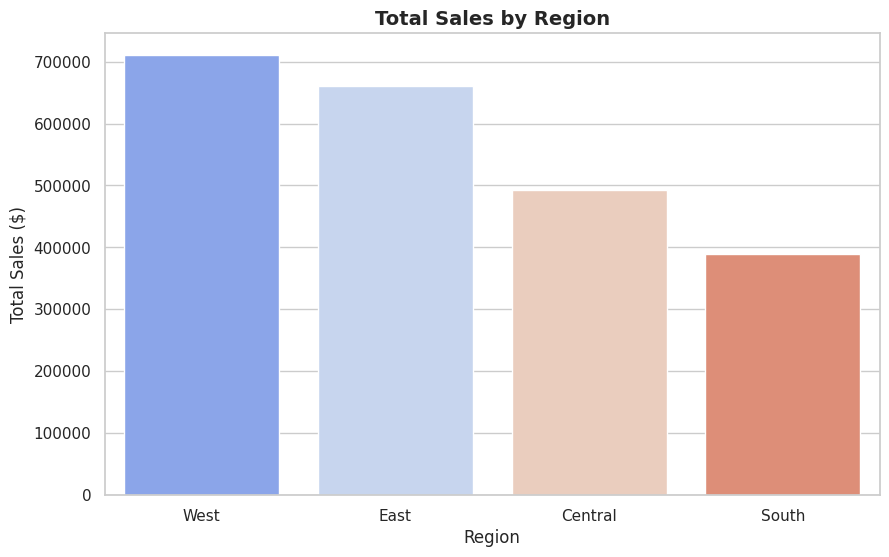

In [ ]:
plt.figure(figsize=(10, 6))
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=region_sales.index, y=region_sales.values, palette='coolwarm')
plt.title('Total Sales by Region')
plt.ylabel('Total Sales ($)')
plt.savefig('region_sales.png', bbox_inches='tight')
plt.show()

**Regional Sales Breakdown :**

There is a significant imbalance across the four regions :

- **West** leads with the highest revenue, generating nearly **1.83× more sales than the South**.
- **East** follows closely behind the West.
- **Central** and especially **South** lag noticeably.

**Strategic implication :** The South and Central regions represent a **clear expansion frontier**. The gap is too large to be explained by population alone, suggesting under-investment in these markets. Targeted marketing campaigns, faster shipping options, regional warehousing, or local distribution partnerships could unlock substantial growth in these underperforming regions.

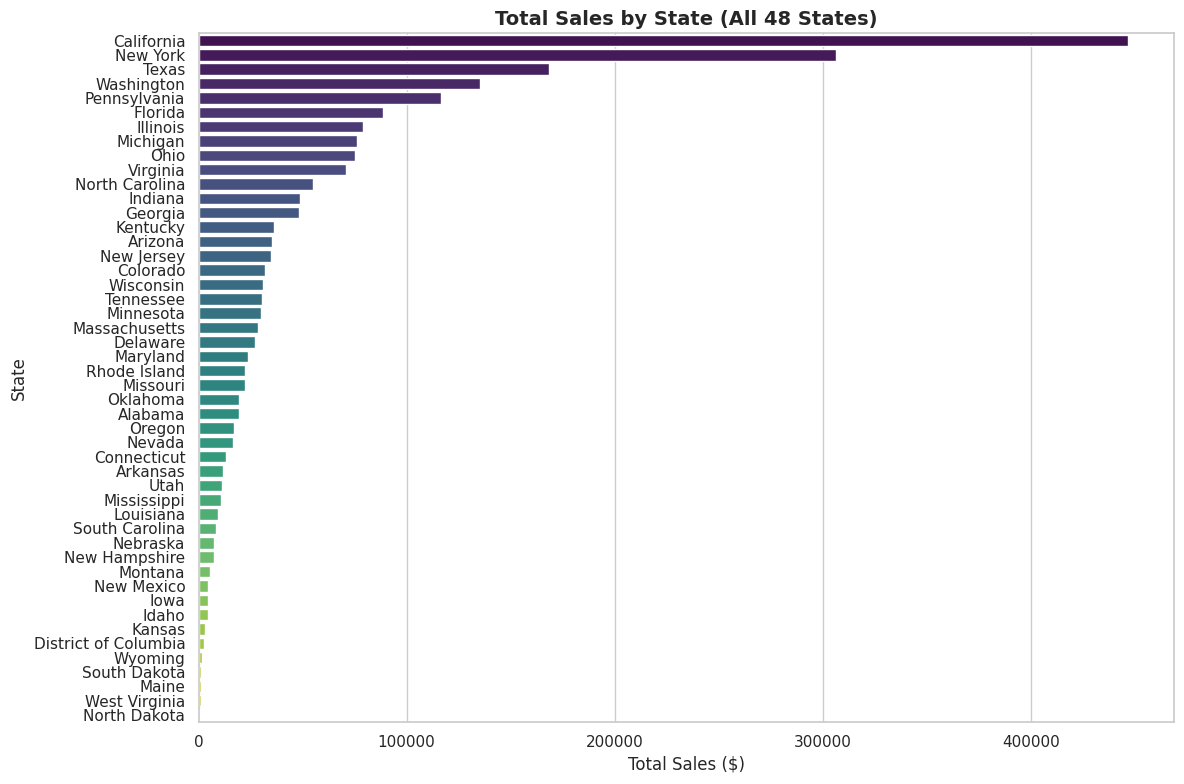

Top 10 States by Revenue:
 State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64

Bottom 10 States by Revenue:
 State
New Mexico              4783.522
Iowa                    4443.560
Idaho                   4382.486
Kansas                  2914.310
District of Columbia    2865.020
Wyoming                 1603.136
South Dakota            1315.560
Maine                   1270.530
West Virginia           1209.824
North Dakota             919.910
Name: Sales, dtype: float64


In [ ]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(x=state_sales.values, y=state_sales.index, palette='viridis')
plt.title('Total Sales by State (All 48 States)')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('state_sales.png', bbox_inches='tight')
plt.show()

print("Top 10 States by Revenue:\n", state_sales.head(10))
print("\nBottom 10 States by Revenue:\n", state_sales.tail(10))

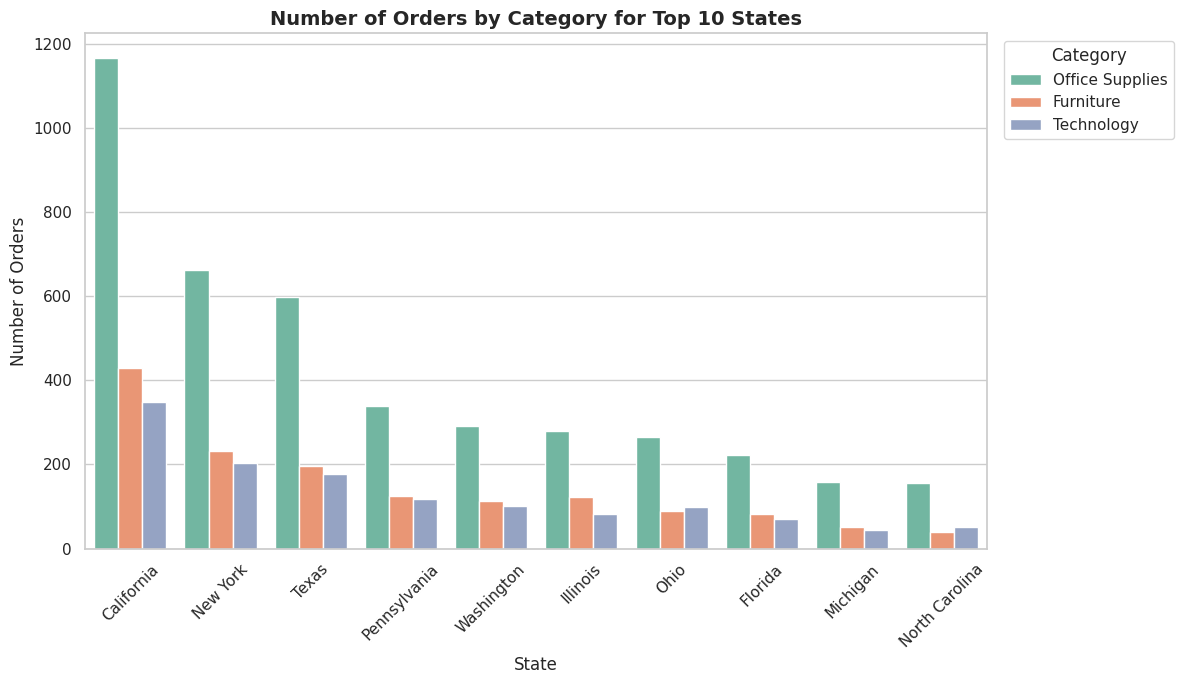

In [ ]:
top_10_states_by_orders = df['State'].value_counts().head(10).index

filtered_df = df[df['State'].isin(top_10_states_by_orders)]

plt.figure(figsize=(12, 7))
sns.countplot(data=filtered_df, x='State', hue='Category', palette='Set2', order=top_10_states_by_orders)

plt.title('Number of Orders by Category for Top 10 States', fontweight='bold', fontsize=14)
plt.xlabel('State', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

**Category Mix Across Top 10 States — Two Important Findings :**

**1. Purchasing behavior is geographically uniform.**
Across all top 10 states, the order is consistently the same : **Office Supplies > Furniture > Technology**. There are no radical regional preferences — customer needs and product mix are remarkably similar nationwide.

**2. Technology is consistently under-represented in volume despite being the #1 revenue category.**
This is the critical insight. Technology has high **value per order** but **low purchase frequency**. The same pattern repeats in every top state.

**Strategic implication :** There is a clear opportunity to develop a stronger marketing and sales plan specifically for Technology products. Tactics like product bundling, financing options, B2B targeted promotions, and educational content could increase tech adoption without sacrificing the high margins that already make this category the top revenue driver.



---



# *8. Product Analysis*

In [ ]:
df['Category'].value_counts()

,count
Category,
Office Supplies,5903
Furniture,2076
Technology,1810


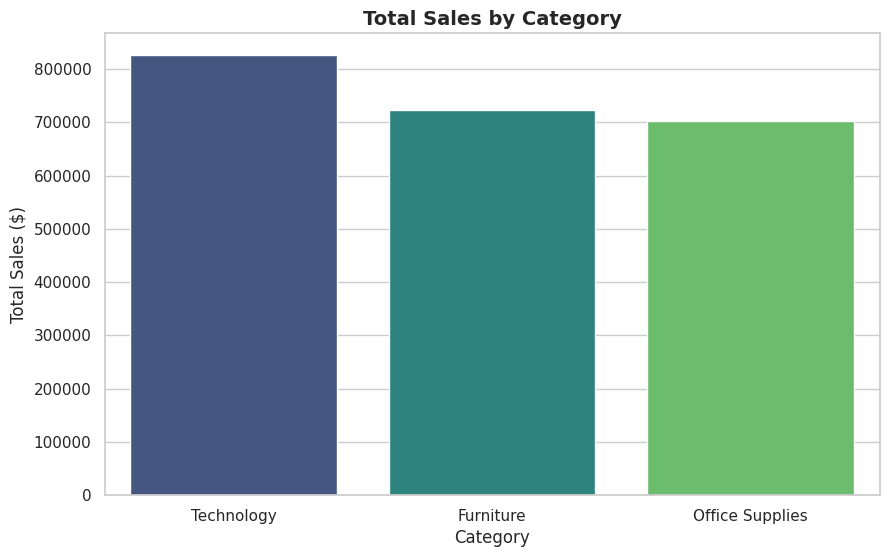

In [ ]:
plt.figure(figsize=(10, 6))
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=cat_sales.index, y=cat_sales.values, palette='viridis')
plt.title('Total Sales by Category')
plt.ylabel('Total Sales ($)')
plt.savefig('category_sales.png', bbox_inches='tight')
plt.show()

**Category Revenue Breakdown :**

The three categories contribute almost equally to total revenue, but each one has very different dynamics behind the numbers.

**Technology 📱** generated around **$826K** which is approximately **37%** of total revenue. What makes this remarkable is that Technology is the **top revenue driver despite having the lowest order count** in the dataset.

**Furniture 🪑** generated around **$724K** which is approximately **32%** of total revenue. This category sits in the middle with balanced revenue and volume.

**Office Supplies 📚** generated around **$703K** which is approximately **31%** of total revenue. This category has the **highest order volume** but the smallest revenue share, which means it sells the most units but at the lowest average price.

**The key insight ✔:** Office Supplies sells the most units, but Technology sells the highest value per transaction. These three categories require completely different sales strategies. Office Supplies needs a high-frequency low-ticket approach with subscriptions and bulk discounts. Furniture needs a quality and design positioning. Technology needs a consultative high-ticket approach with premium service, warranties, and financing. Treating all three with the same marketing strategy wastes the unique strengths of each one.

*Number of Sub-Category :*

In [ ]:
df['Sub-Category'].nunique()

17

*Sub-Categories :*

In [ ]:
df['Sub-Category'].value_counts().head(17)

,count
Sub-Category,
Binders,1492
Paper,1336
Furnishings,931
Phones,875
Storage,831
Art,784
Accessories,754
Chairs,606
Appliances,458


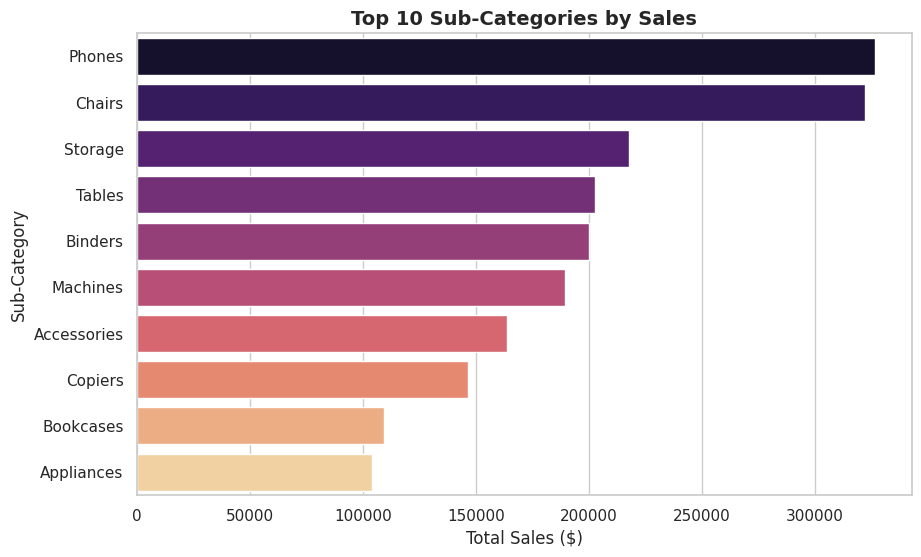

In [ ]:
plt.figure(figsize=(10, 6))
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=subcat_sales.values, y=subcat_sales.index, palette='magma')
plt.title('Top 10 Sub-Categories by Sales')
plt.xlabel('Total Sales ($)')
plt.savefig('subcat_sales.png', bbox_inches='tight')
plt.show()

**Top Sub-Categories by Revenue — Key Insights :**

The breakdown reveals three different revenue patterns :

- **Phones (Technology) and Chairs (Furniture)** are the main revenue drivers — together they generate nearly **29% of total revenue**, making them the company's flagship sub-categories.

- **Binders** had a very high number of transactions but rank only **fifth in revenue**. This is expected since their unit price is relatively low compared to phones and chairs — high volume but low ticket value.

- **Copiers** show the opposite pattern. Despite only **66 transactions** in the entire dataset, they generated around **$150,000** in revenue. This makes Copiers the **highest revenue-per-transaction sub-category** — heavy, profitable, and likely sold to corporate or enterprise buyers.

**Action :** Treat Phones, Chairs, and Copiers as **strategic flagship products** — they deserve premium placement, dedicated marketing campaigns, and tighter inventory management.

*Number of products sold over the years :*

In [ ]:
df['Product Name'].nunique()

1848

*Top 10 products by Revenue :*

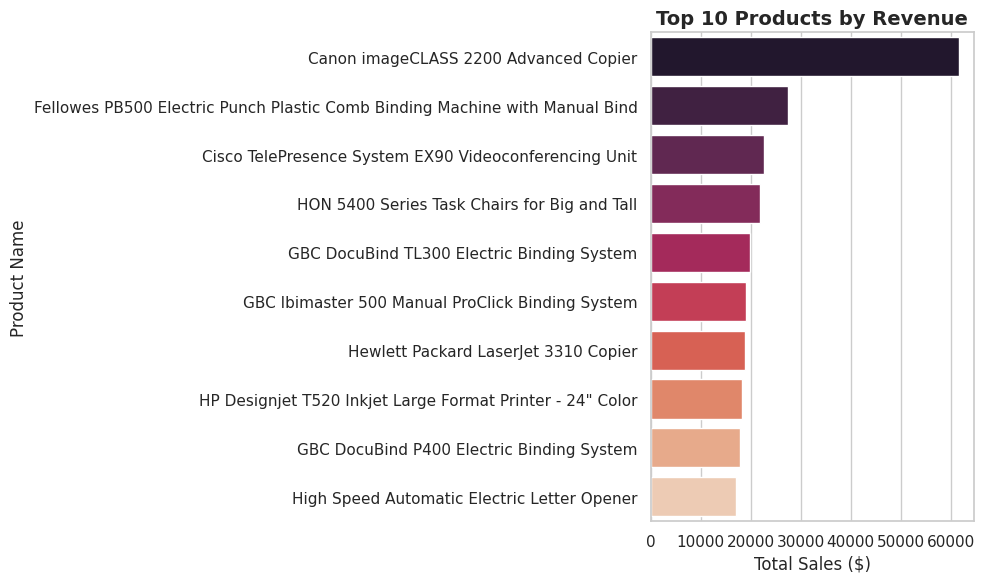

In [ ]:
top_products_revenue = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_products_revenue.values, y=top_products_revenue.index, palette='rocket')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('top_products_revenue.png', bbox_inches='tight')
plt.show()



---



# *9. Sales Distribution & Outliers*

*Total Gross Sales (This value captures the sum of all transactions) :*

In [ ]:
df['Sales'].sum()

np.float64(2252607.4127)

*Sales Summary :*

In [ ]:
df['Sales'].describe()

,Sales
count,9789.000000
mean,230.116193
std,625.302079
min,0.444000
25%,17.248000
50%,54.384000
75%,210.392000
max,22638.480000


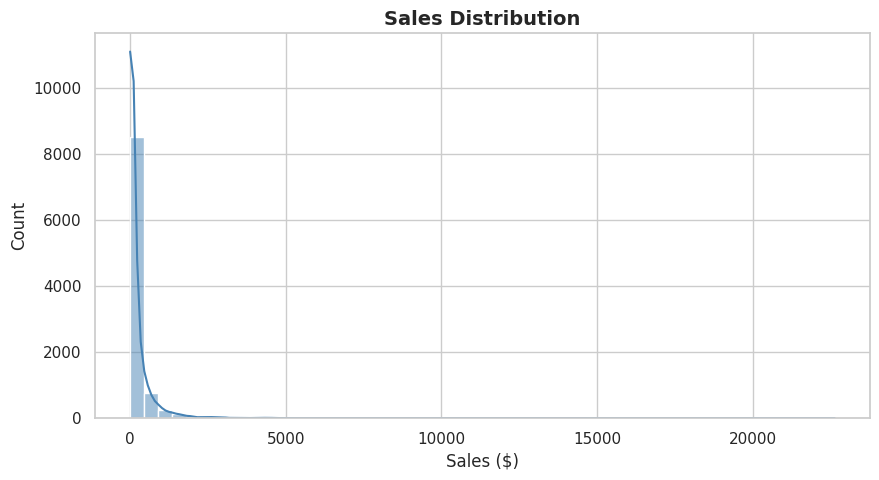

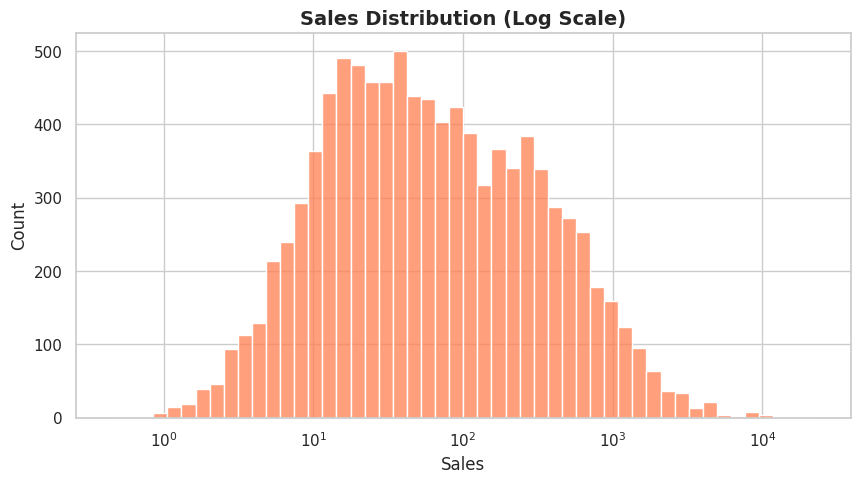

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['Sales'], bins=50, kde=True, color='steelblue')
plt.title('Sales Distribution'); plt.xlabel('Sales ($)'); plt.show()

plt.figure(figsize=(10,5))
sns.histplot(df['Sales'], bins=50, log_scale=True, color='coral')
plt.title('Sales Distribution (Log Scale)'); plt.show()

**Sales Distribution — Linear vs. Log Scale :**

The linear scale chart shows heavy right skew, with most orders below 250 dollars and a long tail stretching to around 22,638 dollars. This confirms the gap between the mean (230 dollars) and the median (54 dollars). The log scale chart reveals a clean bell-shaped curve, meaning the data follows a log-normal distribution typical of e-commerce pricing.

**Why it matters :**
1. **Reporting:** Report the **median ($54)** as the "typical" transaction, not the mean.
2. **Modeling :** Apply a **log transformation** before training any prediction model — performance will improve significantly.
3. **Business :** The long tail isn't noise — it's where **64% of total revenue** lives. The business runs on two parallel modes: many small orders + few high-value orders.

In [ ]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]

outliers.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Order Year,Order Month,Ship Year,Ship Month,Shipping Days
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,2017,11,3
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,2016,10,7
7,8,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,2015,6,2015,6,5
10,11,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,2015,6,2015,6,5
11,12,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,TEC-PH-10002033,Technology,Phones,Konftel 250 Conference phone - Charcoal black,911.4240,2015,6,2015,6,5


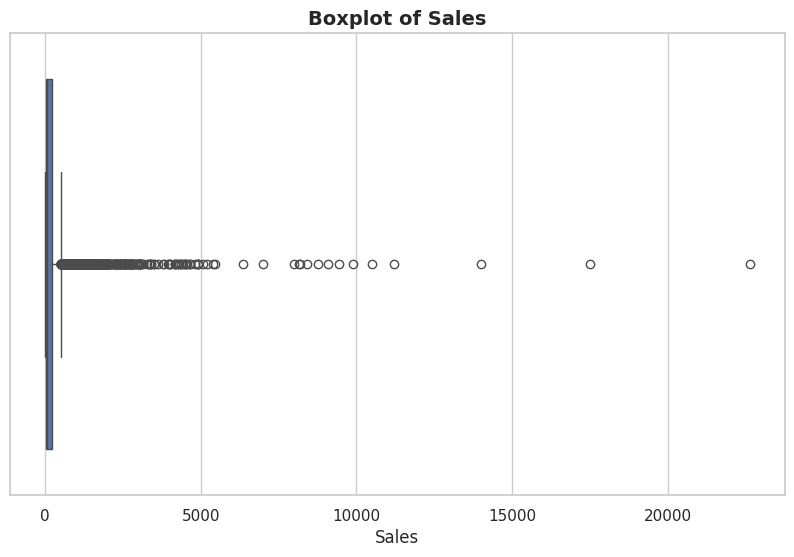

In [ ]:
sns.boxplot(x=df['Sales'])
plt.title('Boxplot of Sales')
plt.show()

**Outlier Detection — IQR Method & Boxplot :**

Q1 is around 17 dollars, Q3 is around 210 dollars, and the upper bound is approximately 500 dollars, meaning any order above 500 dollars is statistically an outlier. The boxplot shows the box is tiny and pushed to the left while the right whisker extends all the way to 22,638 dollars — a textbook case of heavy right skew. The dense cluster of points beyond the whisker confirms there are many outliers, not just a few extreme values.
Critical interpretation: in this dataset, outliers are not errors to remove. They are high-value enterprise orders, VIP customer purchases, and strategic accounts. The next cell will reveal their exact revenue contribution, and the result reframes how the business should think about these outliers entirely.

In [ ]:
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Number of Outliers detected: {len(outliers)}")

Lower Bound: -272.468
Upper Bound: 500.108
Number of Outliers detected: 1141


**Outlier Summary :**

The lower bound is effectively zero **(no low outliers possible)**. The upper bound is around **500 dollars**, so any order above this is an outlier. The total number of outliers detected is around **1,141 orders**, which is about **11.7%**

These outliers are not errors. They are the high-value orders that generate around **64%** of total revenue. They should be analyzed and retained, not removed.



---



# *10. Temporal Analysis*

Yearly Sales:
 Order Year
2015    479856.2081
2016    454315.9054
2017    597225.4900
2018    721209.8092
Name: Sales, dtype: float64

YoY Growth %:
 Order Year
2015      NaN
2016    -5.32
2017    31.46
2018    20.76
Name: Sales, dtype: float64


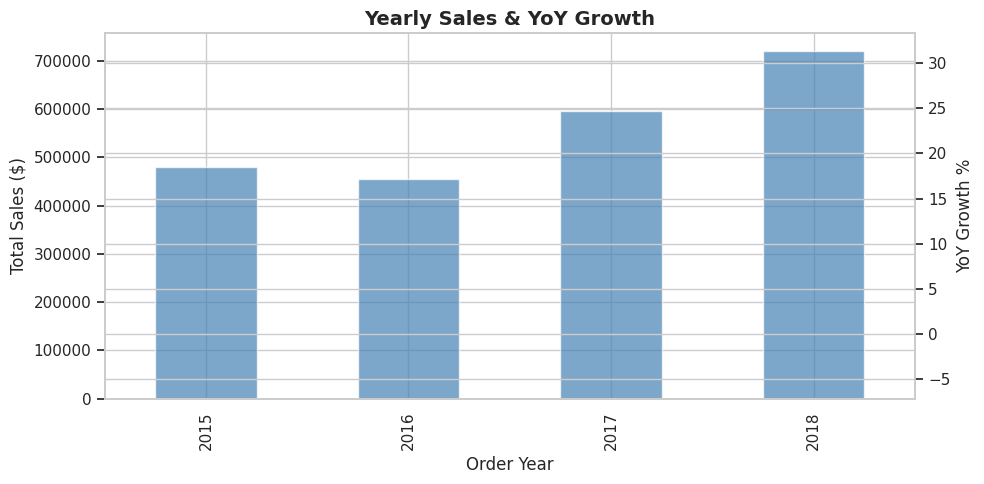

In [ ]:
yearly = df.groupby('Order Year')['Sales'].sum()
yearly_growth = yearly.pct_change() * 100

print("Yearly Sales:\n", yearly)
print("\nYoY Growth %:\n", yearly_growth.round(2))

fig, ax = plt.subplots(figsize=(10,5))
yearly.plot(kind='bar', ax=ax, color='steelblue', alpha=0.7)
ax2 = ax.twinx()
yearly_growth.plot(marker='o', color='red', ax=ax2, linewidth=2)
ax.set_ylabel('Total Sales ($)'); ax2.set_ylabel('YoY Growth %')
plt.title('Yearly Sales & YoY Growth')
plt.tight_layout(); plt.show()

**Year-over-Year Sales Growth :**

The chart tells a clear growth story. Sales started at around **479 thousand dollars** in **2015**, then dipped slightly to **454 thousand** in **2016** which was a decline of **5.3%** . After that the business surged to **597 thousand** in **2017** with growth of **31.5%** and continued climbing to **721 thousand** in **2018** with growth of **20.8%** . Net growth across the four-year span is approximately **50%**

The **2016** dip was a one-time setback and not a structural decline. Since **2017** the business has been in consistent expansion mode with healthy double-digit growth. The slight deceleration from **31.5%** down to **20.8%** is normal as the base gets larger. The next step is to understand what drove the **2017** turnaround so those factors can be sustained going forward.

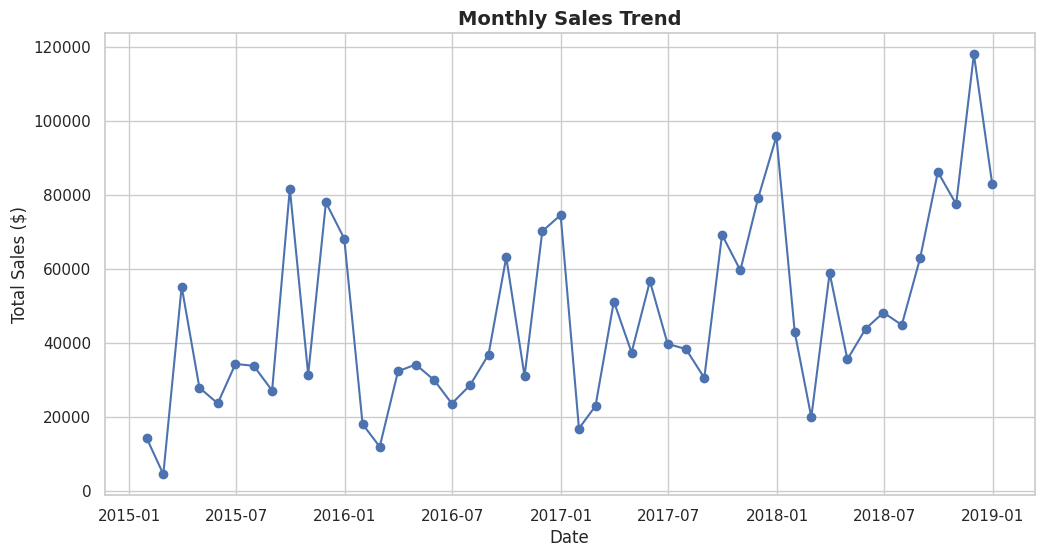

In [ ]:
plt.figure(figsize=(12, 6))
monthly_sales = df.set_index('Order Date').resample('ME')['Sales'].sum()
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.grid(True)
plt.savefig('monthly_sales.png', bbox_inches='tight')
plt.show()

**Monthly Sales Trajectory :**

The line chart illustrates the monthly sales trajectory and provides a clear visualization of seasonal trends and periodic fluctuations. Identifying these historical peaks and dips is essential for understanding market demand cycles and aligning promotional activities with high-growth periods.

We note that **2018** has high sales but also shows unstable patterns with sharper swings between peaks and dips. This volatility may have contributed to the higher number of outliers observed in the sales distribution.

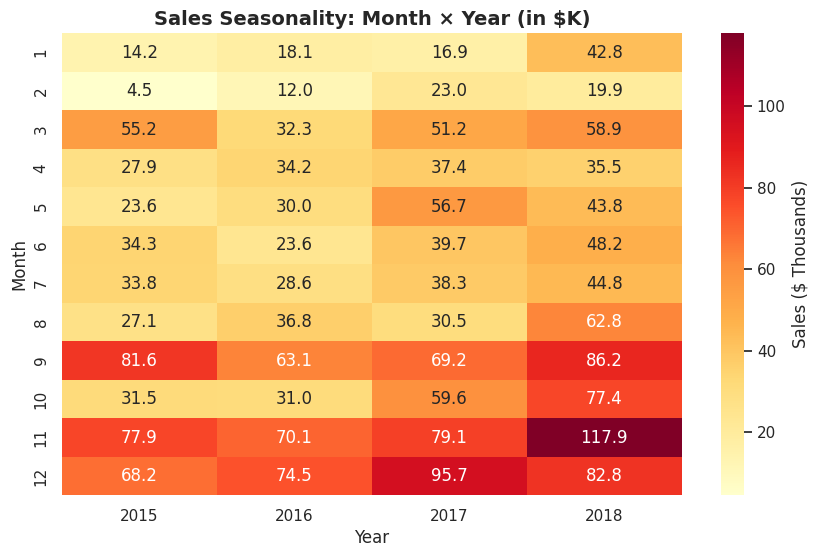

In [ ]:
pivot = df.pivot_table(index='Order Month', columns='Order Year', values='Sales', aggfunc='sum')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot/1000, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': 'Sales ($ Thousands)'})
plt.title('Sales Seasonality: Month × Year (in $K)')
plt.xlabel('Year')
plt.ylabel('Month')
plt.savefig('seasonality_heatmap.png', bbox_inches='tight')
plt.show()

**Sales Seasonality — Month × Year :**

- **November is the peak month every year**, driven by Black Friday and holiday shopping.
- **December and September** follow as the next strongest months.
- **February is consistently the weakest month** — the post-holiday slump.
- The same pattern repeats every year, confirming this is **structural seasonality**, not random.

**Action:** Build up inventory in October, concentrate marketing in Q4, and use February for low-cost internal activities.



---



# 🎯 Key EDA Findings — Summary

### Business Performance
1. **Total Revenue:** $2.25M generated across 4,916 orders (2015–2018).
2. **Growth Trend:** Sales showed YoY growth, with 2018 being the strongest year.
3. **Seasonality:** Clear Q4 peaks (Nov–Dec) — driven by holiday shopping.

### Geographic Insights
4. **Top 3 States** (California, New York, Texas) dominate revenue across all categories.
5. **West Region** leads sales, nearly **double** the South — growth opportunity in South/Central.

### Product Insights
6. **Technology** = highest revenue category despite lower order count.
7. **Phones, Chairs, Storage** are the top revenue drivers.
8. **Copiers** are low-volume / high-margin (66 transactions, $150K revenue).

### Customer Insights
9. **Consumer segment** = 50% of orders; Corporate & Home Office under-tapped.
10. Top customers show consistent engagement (28–35 orders each).

### Shipping Insights
11. **Average shipping time:** 4 days; max 7 days (no extreme delays).
12. **Standard Class** dominates (60%); Same Day under-utilized.

### Data Limitations
- No `Profit` or `Discount` columns → can't analyze margins or pricing strategy.

### Next Steps
- Build interactive dashboard.
- Extract actionable insights & build ML model.